# Capstone Project: Model Selection, Training, Validation, and Evaluation


### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, precision_score, recall_score, f1_score, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/saugataghosh24/online-shoppers-intention/online_shoppers_intention.csv")

print("Shape:", df.shape)
print(df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (12330, 18)
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing Values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0


### Data Cleaning

In [4]:
df.drop_duplicates(inplace=True)

df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)

### Feature Engineering

In [5]:
df['Total_Time'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

### Encoding Categorical Variables

In [6]:
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

### Feature & Target Split

In [7]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

### Class Distribution Check

In [8]:
print("Class Distribution:\n", y.value_counts(normalize=True))

Class Distribution:
 Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64


### Exploratory Data Analysis (EDA)

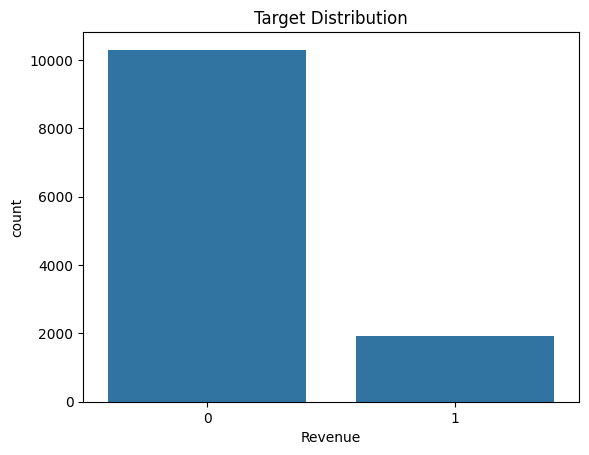

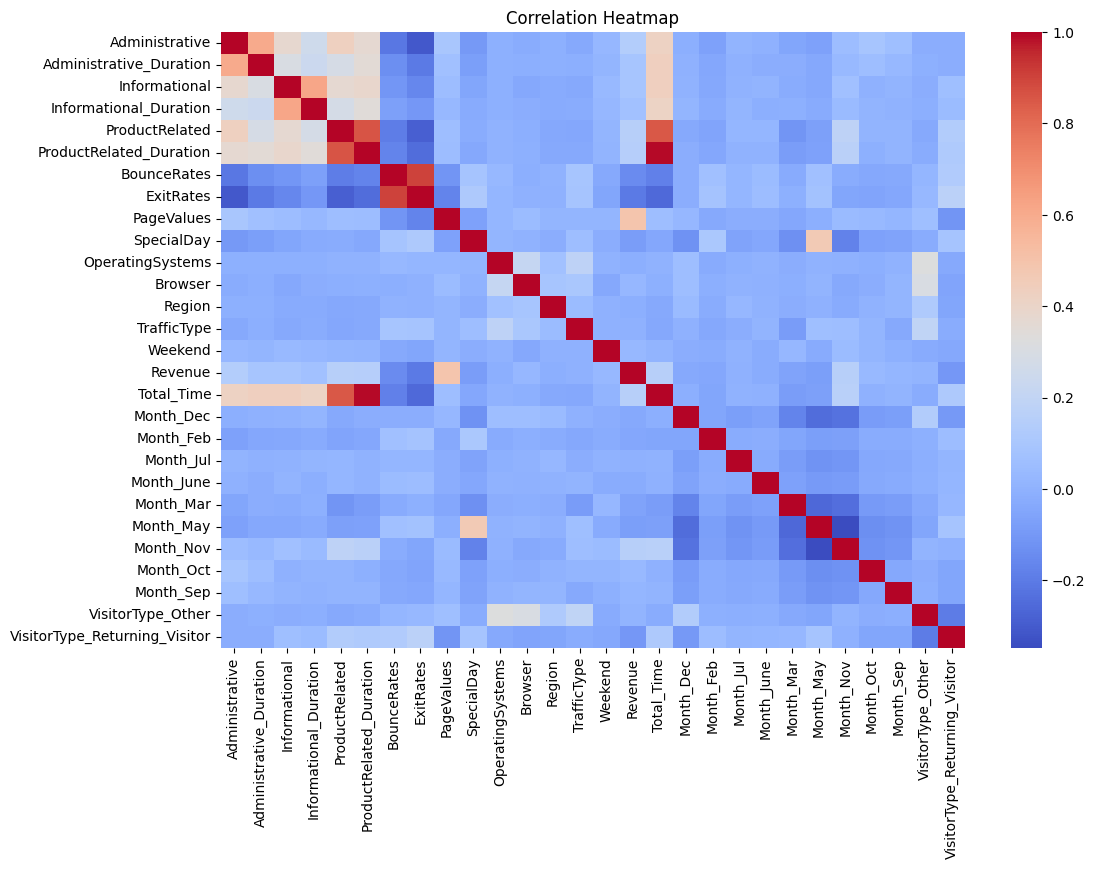

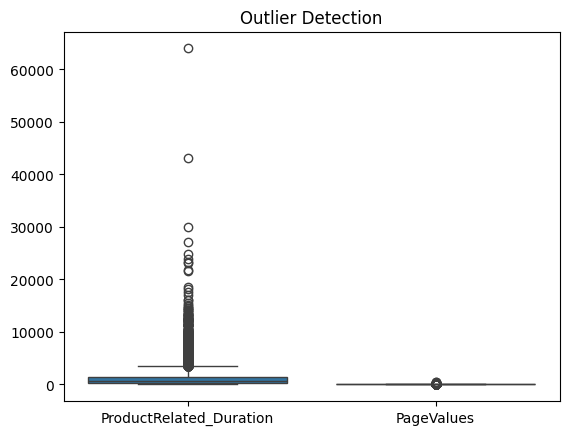

In [9]:
sns.countplot(x='Revenue', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.boxplot(data=df[['ProductRelated_Duration', 'PageValues']])
plt.title("Outlier Detection")
plt.show()

### Train / Validation / Test Split

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

### Feature Scaling (Avoid Data Leakage)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Baseline Model

In [12]:
baseline_pred = [y_train.mode()[0]] * len(y_val)
print("Baseline Accuracy:", accuracy_score(y_val, baseline_pred))

Baseline Accuracy: 0.843801201529219


### Model Training

In [13]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)

# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_val)

# XGBoost (Regularized)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)

### Model Comparison

In [14]:
print("LR:", accuracy_score(y_val, lr_pred))
print("RF:", accuracy_score(y_val, rf_pred))
print("SVM:", accuracy_score(y_val, svm_pred))
print("XGB:", accuracy_score(y_val, xgb_pred))

LR: 0.8902239213544512
RF: 0.9038776624795194
SVM: 0.894593118514473
XGB: 0.8995084653194976


### Cross Validation

In [15]:
print("RF CV:", cross_val_score(rf, X_train, y_train, cv=5).mean())
print("XGB CV:", cross_val_score(xgb, X_train, y_train, cv=5).mean())

RF CV: 0.9000345327053496
XGB CV: 0.8975776403473553


### Hyperparameter Tuning (Final Model)

In [16]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.9044836332791133


### Final Evaluation (Test Set)

In [17]:
y_test_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_test_pred))

Accuracy: 0.9060622610595304
Precision: 0.728
Recall: 0.6363636363636364
F1 Score: 0.6791044776119403
ROC-AUC: 0.9308099667322969
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1545
           1       0.73      0.64      0.68       286

    accuracy                           0.91      1831
   macro avg       0.83      0.80      0.81      1831
weighted avg       0.90      0.91      0.90      1831



### Confusion Matrix

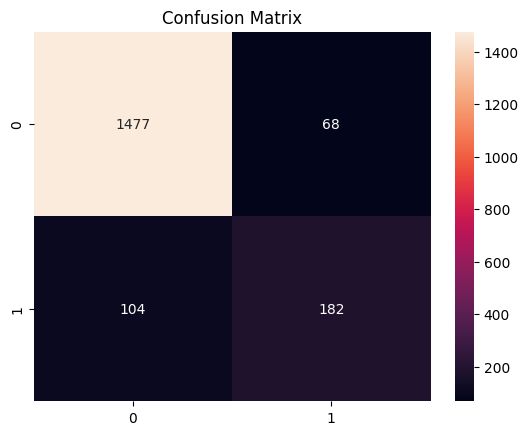

In [18]:
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

###  ROC Curve

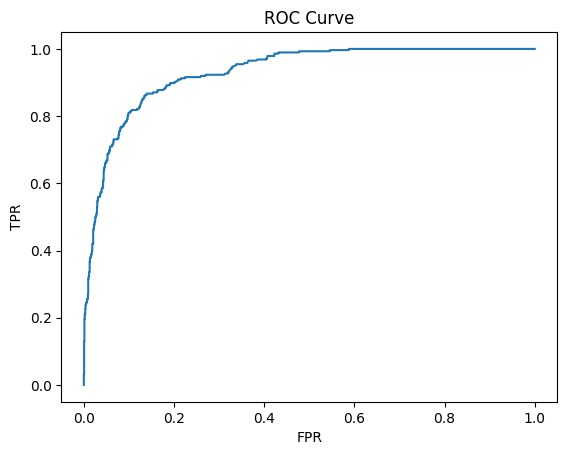

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

### Error Analysis

In [20]:
errors = X_test[y_test != y_test_pred]
print("Misclassified Samples:", len(errors))

Misclassified Samples: 172


### Feature Importance

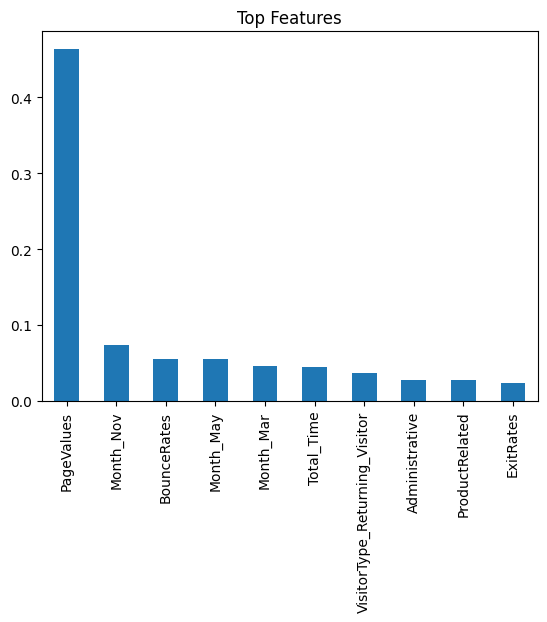

In [21]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

### Model Explainability (Logistic Regression)

In [22]:
coeff = pd.Series(lr.coef_[0], index=X.columns)
print(coeff.sort_values(ascending=False).head(10))

PageValues                 1.497243
Month_Nov                  0.214498
ProductRelated_Duration    0.070610
Informational              0.064640
Total_Time                 0.060115
Weekend                    0.059985
Administrative             0.055613
Browser                    0.047336
TrafficType                0.040004
ProductRelated             0.038275
dtype: float64


### Learning Curve (Overfitting Check)

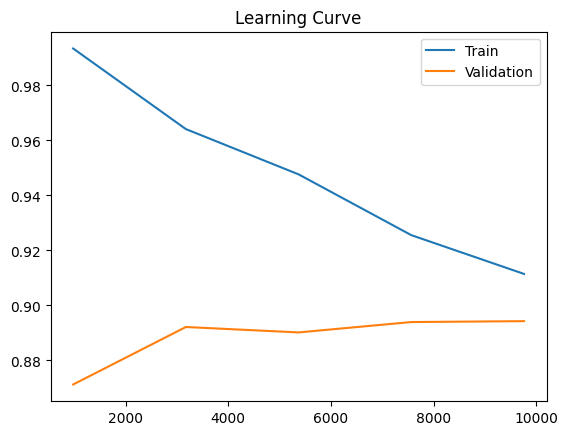

In [23]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")

plt.legend()
plt.title("Learning Curve")
plt.show()

### Robustness Checks

In [24]:
#Stability Across Seeds

rf2 = RandomForestClassifier(random_state=99)
rf2.fit(X_train, y_train)

print("Stability:", accuracy_score(y_test, rf2.predict(X_test)))



#Feature Sensitivity

low_features = importance.tail(5).index
X_reduced = X.drop(columns=low_features)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

rf.fit(X_train_r, y_train_r)

print("After feature removal:",
      accuracy_score(y_test_r, rf.predict(X_test_r)))



#Scaling Sensitivity

rf_no_scale = RandomForestClassifier()
rf_no_scale.fit(X_train, y_train)

print("Without scaling:",
      accuracy_score(y_test, rf_no_scale.predict(X_test)))

Stability: 0.9016930638995084
After feature removal: 0.899631298648095
Without scaling: 0.900600764609503
